# Q3. Feature Engineering and Regression Pipeline

In [25]:
# Task 1 - Date Feature Engineering

import pandas as pd

df = pd.read_csv("../data/q3_retail_promotions.csv")

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.day_of_week

# Month end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [26]:
# Task 2 - Temporal Train-Test Split

# Sort by date
df = df.sort_values(by='transaction_date')

# Split
split_index = int(0.8 * len(df))

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

### Temporal train test split

The dataset is sortedby transation_date and the most recent 20% of data is used as the test set.

A random split is not appropriate for time-based data because it can lead to data leakage, where future information is used to predict the past.

Using a temporal split ensures that the model is evaluated on unseen future data, making it more realistic and reliable

In [27]:
# Task 3 - Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)


nLinear Regression
RMSE:  27.121451164890637
MAE:  21.052926674588395

nRandom Forest
RMSE:  30.841610008504205
MAE:  24.240625


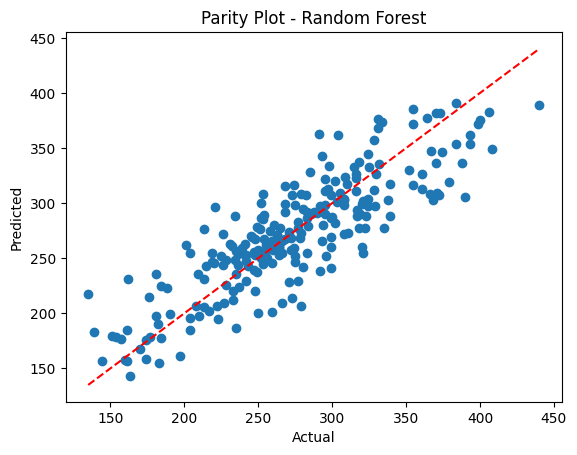

,feature,importance
13,is_festival,0.173473
10,store_size_small,0.167683
7,location_type_urban,0.108378
17,day_of_week,0.086316
12,is_weekend,0.061208


In [28]:
# Task 4 - Model Training and Evaluation

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Pipelines
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# Metrics
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\nn{name}")
    print("RMSE: ", rmse)
    print("MAE: ", mae)

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")

# Parity Plot
import matplotlib.pyplot as plt

# Random forest partity plot
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot - Random Forest")
plt.show()

# Feature Importance
ohe = preprocessor.named_transformers_['cat']
encoded_cols = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_cols) + numerical_cols

rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    "importance": importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(5)